In [3]:
from __future__ import print_function

%matplotlib inline

import numpy
import matplotlib.pyplot as plt

###  3.3.7 Stabilitas dalam Norma $\infty$

Pendekatan yang paling langsung untuk menunjukkan bahwa $||E||_\infty \rightarrow 0$ ketika $\Delta x \rightarrow 0$ adalah dengan menggunakan batas matriks berikut

$$
||E||_\infty \leq \frac{1}{\sqrt{\Delta x}} ||E||_2.
$$

Untuk contoh permasalahan kita, telah ditunjukkan bahwa $||E||_2 = \mathcal{O}(\Delta x^2)$. 
Hal ini mengimplikasikan bahwa setidaknya kita mengetahui bahwa 
$||E||_\infty = \mathcal{O}(\Delta x^{3/2})$.

Hal ini kurang menguntungkan karena secara teoritis kita mengharapkan 
$||E||_\infty = \mathcal{O}(\Delta x^{2})$, yang berasal dari proses diskretisasi. 
Untuk mengatasi permasalahan ini, mari kita kembali mempertimbangkan definisi 
stabilitas yang telah digunakan sebelumnya, tetapi kali ini kita meninjaunya 
dengan menggunakan norma $\infty$.

Matriks $A$ dapat dipandang sebagai sejumlah pendekatan diskret terhadap *fungsi Green* pada setiap kolomnya. 
Konsep ini akan lebih luas penerapannya pada pembahasan selanjutnya, sehingga kita akan meluangkan waktu 
untuk meninjau kembali teori mengenai fungsi Green dan menerapkannya pada contoh permasalahan sederhana kita.

### 3.3.8 Fungsi Green

Pertimbangkan suatu *Boundary Value Problem* (BVP) dengan kondisi batas Dirichlet

$$
u''(x) = f(x) \quad \Omega = [0, 1] \\
u(0) = \alpha \quad u(1) = \beta.
$$

Pilih suatu titik tetap $\bar{x} \in \Omega$. Fungsi Green $G(x ; \bar{x})$ adalah solusi dari BVP di atas dengan

$$
f(x) = \delta(x - \bar{x})
$$

serta $\alpha = \beta = 0$. Hal ini dapat dipahami sebagai hasil dari suatu masalah keadaan tunak (*steady-state*) 
pada persamaan panas, di mana terdapat kehilangan panas pada satu titik tertentu di dalam domain.

Untuk menemukan fungsi Green pada permasalahan khusus kita, kita dapat melakukan integrasi di sekitar titik 
$\bar{x}$ yang berada dekat dengan sumber fungsi $\delta$ sehingga diperoleh

$$\begin{aligned}
\int^{\bar{x} + \epsilon}_{\bar{x} - \epsilon} u''(x) \, dx 
&= \int^{\bar{x} + \epsilon}_{\bar{x} - \epsilon} \delta(x - \bar{x}) \, dx \\
u'(\bar{x} + \epsilon) - u'(\bar{x} - \epsilon) &= 1
\end{aligned}$$

Perlu diingat bahwa secara definisi integral dari fungsi $\delta$ bernilai 1 apabila interval integrasi 
mencakup titik $\bar{x}$. Dari hasil ini terlihat bahwa lompatan (*jump*) turunan pada titik $\bar{x}$, 
dari sisi kiri ke kanan, harus bernilai 1.

Setelah melakukan beberapa langkah aljabar, kita dapat memperoleh fungsi Green untuk model BVP kita sebagai berikut

$$
G(x; \bar{x}) =
\left \{
\begin{aligned}
(\bar{x} - 1)x & \quad 0 \leq x \leq \bar{x} \\
\bar{x}(x - 1) & \quad \bar{x} \leq x \leq 1
\end{aligned}
\right .
$$

Salah satu sifat penting dari PDE linear (atau ODE linear secara umum) adalah bahwa sistem tersebut 
memenuhi prinsip superposisi. Dalam konteks fungsi Green, hal ini berarti bahwa apabila $f(x)$ 
tersusun dari dua fungsi $\delta$, maka solusi yang diperoleh merupakan jumlah dari fungsi Green 
yang bersesuaian.

Sebagai contoh, jika

$$
f(x) = \delta(x - 0.25) + 2 \delta(x - 0.5)
$$

maka solusinya adalah

$$
u(x) = G(x ; 0.25) + 2G(x ; 0.5).
$$

Hal ini tentu saja dapat diperluas menjadi jumlah tak hingga dari fungsi $\delta$ sehingga

$$
f(x) = \int^1_0 f(\bar{x}) \delta(x - \bar{x}) d\bar{x}
$$

dan dengan demikian

$$
u(x) = \int^1_0 f(\bar{x}) G(x ; \bar{x}) d\bar{x}.
$$

Untuk memasukkan pengaruh kondisi batas, kita dapat terus menambahkan fungsi Green ke dalam solusi sehingga diperoleh solusi umum dari BVP semula sebagai

$$
u(x) = \alpha (1 - x) + \beta x + \int^1_0 f(\bar{x}) G(x ; \bar{x}) d\bar{x}.
$$

Lalu mengapa kita melakukan semua ini? Representasi solusi menggunakan fungsi Green di atas dapat dipandang sebagai suatu operator linear yang bekerja pada fungsi $f(x)$. Jika dituliskan dalam bentuk yang lebih familiar, kita memiliki

$$
\mathcal{A} u = f \quad u = \mathcal{A}^{-1} f.
$$

Sekarang kita melihat bahwa operator linear $\mathcal{A}$ dapat dianggap sebagai analog kontinu dari matriks diskret $A$.

Untuk melanjutkan, kita akan memodifikasi matriks $A$ asli menjadi versi yang sedikit berbeda tetapi masih berdasarkan diskretisasi yang sama. Alih-alih memindahkan suku batas ke ruas kanan persamaan, kita akan memperkenalkan dua *unknown* baru yang disebut *ghost cells*, yang ditempatkan pada tepi grid. Kita memberi label titik ini sebagai $U_0$ dan $U_{m+1}$. 

Pada kenyataannya, nilai titik-titik tersebut sudah kita ketahui karena merupakan kondisi batas.

Sistem yang dimodifikasi kemudian menjadi

$$
A = \frac{1}{\Delta x^2}
\begin{bmatrix}
\Delta x^2 & 0  \\
1 & -2 & 1 \\
  & 1 & -2 & 1 \\
  &   & \ddots & \ddots & \ddots \\
  &   &        & 1 & -2 & 1 \\
  &   &        &   & 1 & -2 & 1 \\
  &   &        &   &   & 0 & \Delta x^2
\end{bmatrix}
\quad
U =
\begin{bmatrix}
U_0 \\
U_1 \\
\vdots \\
U_m \\
U_{m+1}
\end{bmatrix}
\quad
F =
\begin{bmatrix}
\alpha \\
f(x_1) \\
\vdots \\
f(x_m) \\
\beta
\end{bmatrix}
$$

Keuntungan dari pendekatan ini adalah bahwa nantinya kita dapat menerapkan kondisi batas yang lebih umum, serta memisahkan ketergantungan aljabar terhadap kondisi batas. Namun kekurangannya adalah bentuk matriks menjadi tidak sesederhana sebelumnya.

Sekarang kita beralih pada bentuk matriks $A^{-1}$. Dengan memperkenalkan sedikit notasi tambahan, misalkan $A_j$ menyatakan kolom ke-$j$ dari matriks $A$, dan $A_{ij}$ menyatakan elemen baris ke-$i$ kolom ke-$j$ dari matriks $A$.

Kita mengetahui bahwa

$$
A A^{-1}_j = e_j
$$

di mana $e_j$ adalah vektor satuan dengan nilai $1$ pada baris ke-$j$ (yaitu kolom ke-$j$ dari matriks identitas).

Perhatikan bahwa sistem di atas memiliki kemiripan dengan versi diskret dari masalah fungsi Green. Di sini $e_j$ merepresentasikan fungsi $\delta$, $A$ adalah operator asli, dan $A^{-1}_j$ menunjukkan pengaruh fungsi $\delta$ ke-$j$ (yang bersesuaian dengan $\bar{x}$) terhadap keseluruhan solusi.

Ternyata kita dapat menuliskan matriks invers secara langsung menggunakan fungsi Green (lihat LeVeque untuk detailnya) sehingga diperoleh

$$
A^{-1}_{ij} =
\Delta x G(x_i ; x_j) =
\left \{
\begin{aligned}
\Delta x (x_j - 1) x_i, & \quad i = 1,2,\ldots,j \\
\Delta x (x_i - 1) x_j, & \quad i = j, j+1, \ldots , m
\end{aligned}
\right .
$$

Kita juga dapat menuliskan ruas kanan efektif dari sistem sebagai

$$
F = \alpha e_0 + \beta e_{m+1} + \sum^m_{j=1} f_j e_j
$$

dan akhirnya solusi sistem menjadi

$$
U = \alpha A^{-1}_{0} + \beta A^{-1}_{m+1} + \sum^m_{j=1} f_j A^{-1}_{j}
$$

dengan elemen-elemen

$$
U_i = \alpha(1 - x_i) + \beta x_i + \Delta x \sum^m_{j=1} f_j G(x_i ; x_j).
$$

Sekarang, apa yang kita peroleh dari semua pembahasan ini? Karena kita telah mengetahui bentuk dari $A^{-1}$, kita dapat menghitung norma $\infty$ dari matriks tersebut.

Ingat bahwa norma $\infty$ dari suatu matriks (yang diturunkan dari norma $\infty$ pada vektor) didefinisikan sebagai

$$
|| C ||_\infty = \max_{0\leq i \leq m+1} \sum^{m+1}_{j=0} |C_{ij}|.
$$

Perhatikan bahwa berdasarkan bentuk matriks $A^{-1}$, jumlah elemen pada baris pertama adalah

$$
\sum^{m+1}_{j=0} A_{0j}^{-1} = 1
$$

dan hal yang sama juga berlaku untuk baris terakhir $A^{-1}_{m+1}$.

Kita juga mengetahui bahwa untuk baris-baris lainnya berlaku $A^{-1}_{i,0} < 1$ dan $A^{-1}_{i,m+1} < 1$.

Baris-baris di tengah juga semuanya terbatas oleh

$$
\sum^{m+1}_{j=0} |A^{-1}_{ij}| \leq 1 + 1 + m \Delta x < 3
$$

dengan menggunakan fakta bahwa

$$
\Delta x = \frac{1}{m+1}.
$$

Dengan demikian, kita dapat menyimpulkan analisis stabilitas ini dengan menyatakan bahwa

$$
||A^{-1}||_\infty < 3 \quad \forall \Delta x.
$$

## 3.4 Kondisi Batas Neumann

Seperti yang telah disebutkan sebelumnya, kita dapat memasukkan jenis kondisi batas lainnya 
ke dalam proses diskretisasi dengan menggunakan versi matriks yang telah dimodifikasi. 
Sekarang kita akan mencoba menerapkan hal tersebut pada permasalahan awal kita, 
tetapi dengan salah satu sisi menggunakan kondisi batas Neumann:

$$
u''(x) = f(x) \quad \Omega = [-1, 1] \\
u(-1) = \alpha \quad u'(1) = \sigma.
$$

**Latihan**

Pertimbangkan masalah berikut

$$
u''(x) = f(x) \quad \Omega = [-1, 1] \\
u(-1) = \alpha \quad u'(1) = \sigma.
$$

dengan solusi eksak

$$
u(x) = -(5 + e)x - (2 + e + e^{-1}) + e^x
$$

Eksplorasi implementasi kondisi batas Neumann dengan cara berikut:

1. Menggunakan pendekatan satu sisi (*one-sided*) orde pertama.
2. Menggunakan pendekatan pusat (*centered*) orde kedua.
3. Menggunakan pendekatan satu sisi (*one-sided*) orde kedua.

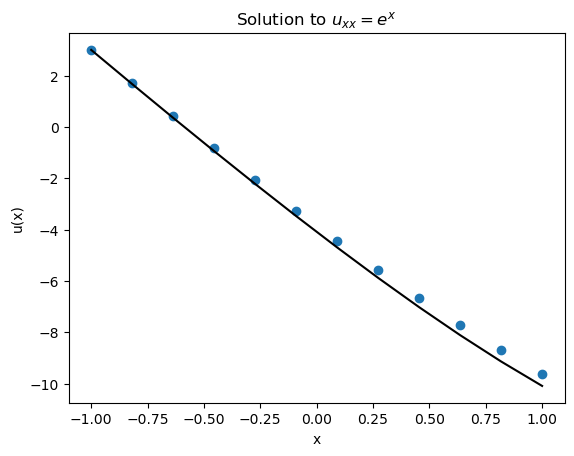

In [4]:
def solve_mixed_1st_order_one_sided(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)

    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)

    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = 1.0 / (delta_x)
    A[-1, -2] = -1.0 / (delta_x)

    b[0] = alpha
    b[-1] = sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U


u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x)

x_bc, U = solve_mixed_1st_order_one_sided(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

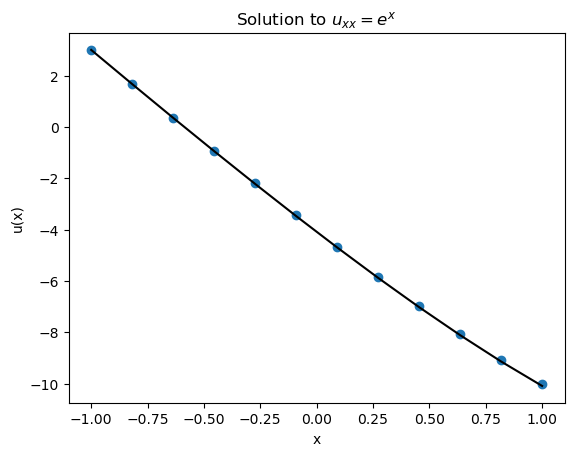

In [5]:
def solve_mixed_2nd_order_one_sided(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)
    
    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)
    
    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = 3.0 / (2.0 * delta_x)
    A[-1, -2] = -4.0 / (2.0 * delta_x)
    A[-1, -3] = 1.0 / (2.0 * delta_x)

    b[0] = alpha
    b[-1] = sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U

x_bc, U = solve_mixed_2nd_order_one_sided(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

In [7]:
# Problem setup
a = -1.0
b = 1.0
alpha = 3.0
sigma = -5.0
f = lambda x: numpy.exp(x)
u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x)

# Compute the error as a function of delta_x
m_range = numpy.arange(10, 200, 20)
delta_x = numpy.empty(m_range.shape)
error = numpy.empty((m_range.shape[0], 3))
for (i, m) in enumerate(m_range):
    
    x = numpy.linspace(a, b, m + 2)
    delta_x[i] = (b - a) / (m + 1)

    # Compute solution
    _, U = solve_mixed_1st_order_one_sided(m)
    error[i, 0] = numpy.linalg.norm(U - u_true(x), ord=numpy.infty)
    _, U = solve_mixed_2nd_order_one_sided(m)
    error[i, 1] = numpy.linalg.norm(U - u_true(x), ord=numpy.infty)
    _, U = solve_mixed_2nd_order_centered(m)
    error[i, 2] = numpy.linalg.norm(U - u_true(x), ord=numpy.infty)
    
titles = ["1st Order, One-Sided", "2nd Order, Centered", "2nd Order, One-Sided"]
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
for i in range(3):
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)

    axes.loglog(delta_x, error[:, i], 'ko', label="Approx. Derivative")

    axes.loglog(delta_x, order_C(delta_x[0], error[0,i], 1.0) * delta_x**1.0, 'r--', label="1st Order")
    axes.loglog(delta_x, order_C(delta_x[0], error[0,i], 2.0) * delta_x**2.0, 'b--', label="2nd Order")
    axes.legend(loc=4)
    axes.set_title(titles[i])
    axes.set_xlabel("$\Delta x$")
    axes.set_ylabel("$|u(x) - U|$")


plt.show()

U = solve_mixed_1st_order_one_sided(10)
U = solve_mixed_2nd_order_one_sided(10)
U = solve_mixed_2nd_order_centered(10)

NameError: name 'solve_mixed_2nd_order_centered' is not defined